<a href="https://colab.research.google.com/github/qmafaza/CI-Projek-BOA/blob/main/BOA_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install gdown to handle Google Drive downloads, including those with virus warnings
!pip install gdown

In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
import gdown
import re

In [3]:
# The link
link = 'https://drive.google.com/uc?export=download&id=1BFPKsWIxC2uJ9a1bQANvmRRv1kfC52UJ'

# Extract the file ID from the link
match = re.search(r'id=([\w-]+)', link)
file_id = None
if match:
    file_id = match.group(1)
else:
    print("Error: Could not extract file ID from the provided link.")

if file_id:
    # Define the output path for the downloaded CSV
    output_file_name = 'train_preprocessed.csv'

    try:
        # Use gdown to download the file. It automatically handles the 'download anyway' prompt.
        print(f"Attempting to download file ID: {file_id} using gdown...")
        gdown.download(id=file_id, output=output_file_name, quiet=False)
        print(f"Successfully downloaded '{output_file_name}'.")

        # Load the downloaded CSV into a pandas DataFrame
        train_df = pd.read_csv(output_file_name)
        print(f"Successfully loaded '{output_file_name}' into DataFrame. First 5 rows:")
        display(train_df.head())

    except Exception as e:
        print(f"An error occurred during download or loading: {e}")
else:
    print("Cannot proceed without a valid Google Drive file ID.")

Attempting to download file ID: 1BFPKsWIxC2uJ9a1bQANvmRRv1kfC52UJ using gdown...


Downloading...
From (original): https://drive.google.com/uc?id=1BFPKsWIxC2uJ9a1bQANvmRRv1kfC52UJ
From (redirected): https://drive.google.com/uc?id=1BFPKsWIxC2uJ9a1bQANvmRRv1kfC52UJ&confirm=t&uuid=653cbe0c-f813-411f-b556-d6c49cc971cd
To: /content/train_preprocessed.csv
100%|██████████| 651M/651M [00:08<00:00, 73.4MB/s]


Successfully downloaded 'train_preprocessed.csv'.
Successfully loaded 'train_preprocessed.csv' into DataFrame. First 5 rows:


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1,1.030764
1,2012-04-08 07:30:50.0000002,5.3,2012-04-08 07:30:50 UTC,-73.996335,40.737142,-73.980721,40.733559,1,1.374577
2,2011-04-05 17:11:05.0000001,7.7,2011-04-05 17:11:05 UTC,-74.001821,40.737547,-73.998060,40.722788,2,1.671445
3,2009-07-22 16:08:00.000000163,5.3,2009-07-22 16:08:00 UTC,-73.981060,40.737690,-73.994177,40.728412,1,1.511904
4,2011-06-28 19:47:00.000000168,4.5,2011-06-28 19:47:00 UTC,-73.988893,40.760160,-73.986445,40.757857,3,0.328771


In [4]:
from sklearn.model_selection import train_test_split

# Assuming `train_df` is already loaded and preprocessed
# Split train_df into 80% train and 20% test
new_train_df, new_test_df = train_test_split(train_df, test_size=0.2, random_state=42)

# Overwrite the existing train_df and test_df with the new split data
train_df = new_train_df
test_df = new_test_df

print("New train_df shape:", train_df.shape)
print("New test_df shape:", test_df.shape)

print("First 5 rows of the new train_df:")
display(train_df.head())
print("\nFirst 5 rows of the new test_df:")
display(test_df.head())

New train_df shape: (4294896, 9)
New test_df shape: (1073724, 9)
First 5 rows of the new train_df:


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance
2215439,2012-02-27 07:16:51.0000002,6.9,2012-02-27 07:16:51 UTC,-73.977934,40.752644,-73.993802,40.745121,1,1.576875
437726,2011-11-26 15:36:55.0000001,9.7,2011-11-26 15:36:55 UTC,-74.006396,40.743654,-73.978440,40.764426,1,3.298480
2517204,2010-03-13 09:05:53.0000001,5.3,2010-03-13 09:05:53 UTC,-73.973274,40.747832,-73.973548,40.756839,1,1.001799
1056046,2009-04-25 18:52:00.00000048,5.3,2009-04-25 18:52:00 UTC,-74.005575,40.740585,-73.995508,40.739123,5,0.863586
3352386,2009-03-21 20:45:00.00000012,8.5,2009-03-21 20:45:00 UTC,-73.983352,40.741990,-73.992667,40.720407,4,2.525010



First 5 rows of the new test_df:


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance
4616041,2014-04-01 23:02:51.0000001,19.0,2014-04-01 23:02:51 UTC,-73.986389,40.762565,-74.013823,40.708880,1,6.401390
203889,2009-08-26 12:59:53.0000001,6.9,2009-08-26 12:59:53 UTC,-73.974006,40.756800,-73.985282,40.749195,1,1.271714
4401329,2013-12-08 14:32:30.0000002,16.0,2013-12-08 14:32:30 UTC,-73.957119,40.770117,-73.993908,40.758919,1,3.339175
2559533,2011-08-06 00:18:00.000000206,17.7,2011-08-06 00:18:00 UTC,-73.962877,40.717185,-73.982463,40.731407,3,2.285838
5123324,2010-02-18 19:21:32.0000003,10.5,2010-02-18 19:21:32 UTC,-73.994092,40.751120,-73.980214,40.744429,1,1.385751


## Prepare Data and Feature Engineering

### Subtask:
Clean and preprocess the `train_df` and `test_df` DataFrames, including converting `pickup_datetime` to datetime objects, extracting relevant features, and handling missing values and outliers.


**Reasoning**:
The first step in data preprocessing is to convert the 'pickup_datetime' column to datetime objects for both `train_df` and `test_df` and then extract relevant time-based features like year, month, day, weekday, and hour, as specified in the instructions.



In [5]:
for df in [train_df, test_df]:
    df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
    df['year'] = df['pickup_datetime'].dt.year
    df['month'] = df['pickup_datetime'].dt.month
    df['day'] = df['pickup_datetime'].dt.day
    df['weekday'] = df['pickup_datetime'].dt.weekday
    df['hour'] = df['pickup_datetime'].dt.hour

print("Extracted time-based features from train_df:")
display(train_df.head())
print("\nExtracted time-based features from test_df:")
display(test_df.head())

Extracted time-based features from train_df:


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance,year,month,day,weekday,hour
2215439,2012-02-27 07:16:51.0000002,6.9,2012-02-27 07:16:51+00:00,-73.977934,40.752644,-73.993802,40.745121,1,1.576875,2012,2,27,0,7
437726,2011-11-26 15:36:55.0000001,9.7,2011-11-26 15:36:55+00:00,-74.006396,40.743654,-73.978440,40.764426,1,3.298480,2011,11,26,5,15
2517204,2010-03-13 09:05:53.0000001,5.3,2010-03-13 09:05:53+00:00,-73.973274,40.747832,-73.973548,40.756839,1,1.001799,2010,3,13,5,9
1056046,2009-04-25 18:52:00.00000048,5.3,2009-04-25 18:52:00+00:00,-74.005575,40.740585,-73.995508,40.739123,5,0.863586,2009,4,25,5,18
3352386,2009-03-21 20:45:00.00000012,8.5,2009-03-21 20:45:00+00:00,-73.983352,40.741990,-73.992667,40.720407,4,2.525010,2009,3,21,5,20



Extracted time-based features from test_df:


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance,year,month,day,weekday,hour
4616041,2014-04-01 23:02:51.0000001,19.0,2014-04-01 23:02:51+00:00,-73.986389,40.762565,-74.013823,40.708880,1,6.401390,2014,4,1,1,23
203889,2009-08-26 12:59:53.0000001,6.9,2009-08-26 12:59:53+00:00,-73.974006,40.756800,-73.985282,40.749195,1,1.271714,2009,8,26,2,12
4401329,2013-12-08 14:32:30.0000002,16.0,2013-12-08 14:32:30+00:00,-73.957119,40.770117,-73.993908,40.758919,1,3.339175,2013,12,8,6,14
2559533,2011-08-06 00:18:00.000000206,17.7,2011-08-06 00:18:00+00:00,-73.962877,40.717185,-73.982463,40.731407,3,2.285838,2011,8,6,5,0
5123324,2010-02-18 19:21:32.0000003,10.5,2010-02-18 19:21:32+00:00,-73.994092,40.751120,-73.980214,40.744429,1,1.385751,2010,2,18,3,19


**Reasoning**:
The next step is to handle outliers in the `train_df` for `fare_amount` and `passenger_count`, and then apply geographical bounds to filter out invalid coordinates in both `train_df` and `test_df` as specified in the instructions.



In [6]:
print("Original train_df shape:", train_df.shape)
print("Original test_df shape:", test_df.shape)

# Remove outliers for fare_amount in train_df
train_df = train_df[(train_df['fare_amount'] > 0) & (train_df['fare_amount'] <= 200)]
print("train_df shape after fare_amount outlier removal:", train_df.shape)

# Remove outliers for passenger_count in train_df
train_df = train_df[(train_df['passenger_count'] > 0) & (train_df['passenger_count'] <= 6)]
print("train_df shape after passenger_count outlier removal:", train_df.shape)

# Define geographical bounds for NYC
min_longitude = -74.26
max_longitude = -73.68
min_latitude = 40.57
max_latitude = 40.92

# Function to filter out rows with coordinates outside NYC bounds
def filter_nyc_bounds(df):
    return df[
        (df['pickup_longitude'] >= min_longitude) & (df['pickup_longitude'] <= max_longitude) &
        (df['dropoff_longitude'] >= min_longitude) & (df['dropoff_longitude'] <= max_longitude) &
        (df['pickup_latitude'] >= min_latitude) & (df['pickup_latitude'] <= max_latitude) &
        (df['dropoff_latitude'] >= min_latitude) & (df['dropoff_latitude'] <= max_latitude)
    ]

# Apply geographical bounds filtering to both train_df and test_df
original_train_shape = train_df.shape
original_test_shape = test_df.shape

train_df = filter_nyc_bounds(train_df)
test_df = filter_nyc_bounds(test_df)

print("train_df shape after geographical bounds filtering:", train_df.shape)
print("test_df shape after geographical bounds filtering:", test_df.shape)

print("First 5 rows of train_df after outlier handling:")
display(train_df.head())
print("First 5 rows of test_df after outlier handling:")
display(test_df.head())

Original train_df shape: (4294896, 14)
Original test_df shape: (1073724, 14)
train_df shape after fare_amount outlier removal: (4294805, 14)
train_df shape after passenger_count outlier removal: (4279664, 14)
train_df shape after geographical bounds filtering: (4271754, 14)
test_df shape after geographical bounds filtering: (1071733, 14)
First 5 rows of train_df after outlier handling:


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance,year,month,day,weekday,hour
2215439,2012-02-27 07:16:51.0000002,6.9,2012-02-27 07:16:51+00:00,-73.977934,40.752644,-73.993802,40.745121,1,1.576875,2012,2,27,0,7
437726,2011-11-26 15:36:55.0000001,9.7,2011-11-26 15:36:55+00:00,-74.006396,40.743654,-73.978440,40.764426,1,3.298480,2011,11,26,5,15
2517204,2010-03-13 09:05:53.0000001,5.3,2010-03-13 09:05:53+00:00,-73.973274,40.747832,-73.973548,40.756839,1,1.001799,2010,3,13,5,9
1056046,2009-04-25 18:52:00.00000048,5.3,2009-04-25 18:52:00+00:00,-74.005575,40.740585,-73.995508,40.739123,5,0.863586,2009,4,25,5,18
3352386,2009-03-21 20:45:00.00000012,8.5,2009-03-21 20:45:00+00:00,-73.983352,40.741990,-73.992667,40.720407,4,2.525010,2009,3,21,5,20


First 5 rows of test_df after outlier handling:


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance,year,month,day,weekday,hour
4616041,2014-04-01 23:02:51.0000001,19.0,2014-04-01 23:02:51+00:00,-73.986389,40.762565,-74.013823,40.708880,1,6.401390,2014,4,1,1,23
203889,2009-08-26 12:59:53.0000001,6.9,2009-08-26 12:59:53+00:00,-73.974006,40.756800,-73.985282,40.749195,1,1.271714,2009,8,26,2,12
4401329,2013-12-08 14:32:30.0000002,16.0,2013-12-08 14:32:30+00:00,-73.957119,40.770117,-73.993908,40.758919,1,3.339175,2013,12,8,6,14
2559533,2011-08-06 00:18:00.000000206,17.7,2011-08-06 00:18:00+00:00,-73.962877,40.717185,-73.982463,40.731407,3,2.285838,2011,8,6,5,0
5123324,2010-02-18 19:21:32.0000003,10.5,2010-02-18 19:21:32+00:00,-73.994092,40.751120,-73.980214,40.744429,1,1.385751,2010,2,18,3,19


## Prepare X_train, X_test, y_train, y_test

In [7]:
# Define features (X) and target (y)
features = ['distance', 'passenger_count']
target = 'fare_amount'

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nFirst 5 rows of X_train:")
display(X_train.head())
print("\nFirst 5 rows of y_train:")
display(y_train.head())

X_train shape: (4271754, 2)
y_train shape: (4271754,)
X_test shape: (1071733, 2)
y_test shape: (1071733,)

First 5 rows of X_train:


,distance,passenger_count
2215439,1.576875,1
437726,3.298480,1
2517204,1.001799,1
1056046,0.863586,5
3352386,2.525010,4



First 5 rows of y_train:


,fare_amount
2215439,6.9
437726,9.7
2517204,5.3
1056046,5.3
3352386,8.5


## Fungsi bantu: polynomial + closed form

In [8]:
def add_bias(X):
    ones = np.ones((X.shape[0], 1))
    return np.hstack([ones, X])

def apply_polynomial(X, degree):
    if degree == 1:
        return X
    elif degree == 2:
        x1 = X[:, 0]
        x2 = X[:, 1]
        return np.column_stack([X, x1**2, x2**2, x1*x2])
    elif degree == 3:
        x1 = X[:, 0]
        x2 = X[:, 1]
        return np.column_stack([X,
                                x1**2, x2**2, x1*x2,
                                x1**3, x2**3])


## Fungsi Closed-Form Linear Regression

In [9]:
def closed_form_train_predict(X_train, y_train, X_test):
    X_train_bias = add_bias(X_train)
    X_test_bias  = add_bias(X_test)

    # closed form solution: W = (X'X)^(-1) X'y
    W = np.linalg.inv(X_train_bias.T @ X_train_bias) @ (X_train_bias.T @ y_train)

    return X_test_bias @ W

## Fungsi Fitness BOA (RMSE Validation)

In [10]:
def fitness(params):
    scale, degree = params

    # scaling
    X_train_scaled = X_train * scale
    X_test_scaled = X_test * scale

    # polynomial transform, converting to numpy arrays for array-like indexing
    X_train_poly = apply_polynomial(X_train_scaled.values, int(degree))
    X_test_poly = apply_polynomial(X_test_scaled.values, int(degree))

    # closed-form prediction
    y_pred = closed_form_train_predict(X_train_poly, y_train, X_test_poly)

    # RMSE
    return np.sqrt(mean_squared_error(y_test, y_pred))

## BOA Setup

In [11]:
num_butterflies = 20
max_iter = 40

lower_bound = np.array([0.1, 1])   # scale, degree
upper_bound = np.array([3.0, 3])

a = 0.1
c = 0.01
p = 0.6

population = np.random.uniform(lower_bound, upper_bound, (num_butterflies, 2))
fitness_values = np.array([fitness(p) for p in population])

global_best = population[np.argmin(fitness_values)]
global_best_fitness = np.min(fitness_values)

convergence = []


## BOA Optimization Loop

In [13]:
for t in range(max_iter):
    for i in range(num_butterflies):

        f_i = c * (fitness_values[i] ** a)
        r = np.random.rand()

        if r < p:
            new_pos = population[i] + (r*r * global_best - population[i]) * f_i
        else:
            j, k = np.random.choice(num_butterflies, 2, replace=False)
            new_pos = population[i] + (r*r * population[j] - population[k]) * f_i

        new_pos = np.clip(new_pos, lower_bound, upper_bound)

        new_fit = fitness(new_pos)

        if new_fit < fitness_values[i]:
            population[i], fitness_values[i] = new_pos, new_fit

    best_idx = np.argmin(fitness_values)
    if fitness_values[best_idx] < global_best_fitness:
        global_best = population[best_idx]
        global_best_fitness = fitness_values[best_idx]

    convergence.append(global_best_fitness)

    print(f"Iterasi {t+1}/{max_iter} → Best RMSE: {global_best_fitness:.4f}")

print("\nOptimasi selesai!")
print("Best scale:", global_best[0])
print("Best degree:", int(global_best[1]))
print("Best RMSE:", global_best_fitness)

Iterasi 1/40 → Best RMSE: 4.4769
Iterasi 2/40 → Best RMSE: 4.4769
Iterasi 3/40 → Best RMSE: 4.4769
Iterasi 4/40 → Best RMSE: 4.4769
Iterasi 5/40 → Best RMSE: 4.4769
Iterasi 6/40 → Best RMSE: 4.4769
Iterasi 7/40 → Best RMSE: 4.4769
Iterasi 8/40 → Best RMSE: 4.4769
Iterasi 9/40 → Best RMSE: 4.4769
Iterasi 10/40 → Best RMSE: 4.4769
Iterasi 11/40 → Best RMSE: 4.4769
Iterasi 12/40 → Best RMSE: 4.4769
Iterasi 13/40 → Best RMSE: 4.4769
Iterasi 14/40 → Best RMSE: 4.4769
Iterasi 15/40 → Best RMSE: 4.4769
Iterasi 16/40 → Best RMSE: 4.4769
Iterasi 17/40 → Best RMSE: 4.4769
Iterasi 18/40 → Best RMSE: 4.4769
Iterasi 19/40 → Best RMSE: 4.4769
Iterasi 20/40 → Best RMSE: 4.4769
Iterasi 21/40 → Best RMSE: 4.4769
Iterasi 22/40 → Best RMSE: 4.4769
Iterasi 23/40 → Best RMSE: 4.4769
Iterasi 24/40 → Best RMSE: 4.4769
Iterasi 25/40 → Best RMSE: 4.4769
Iterasi 26/40 → Best RMSE: 4.4769
Iterasi 27/40 → Best RMSE: 4.4769
Iterasi 28/40 → Best RMSE: 4.4769
Iterasi 29/40 → Best RMSE: 4.4769
Iterasi 30/40 → Best RM

## Plot Konvergensi

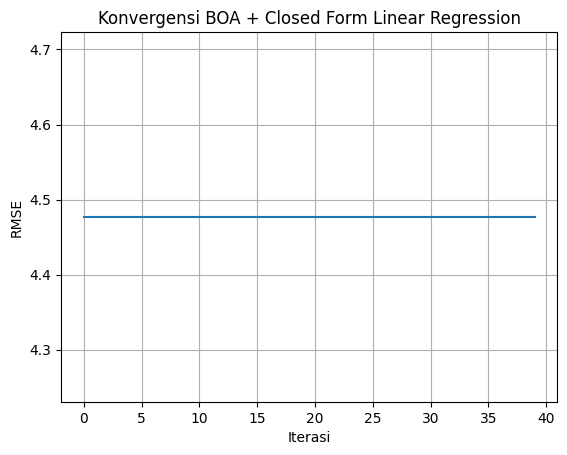

In [14]:
plt.plot(convergence)
plt.title("Konvergensi BOA + Closed Form Linear Regression")
plt.xlabel("Iterasi")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()

## Evaluasi Model Final

In [16]:
# Extract best scale and degree from global_best
best_scale = global_best[0]
best_degree = int(global_best[1])

# Apply scaling and polynomial transformation to X_train and X_test using the best parameters
X_train_scaled_final = X_train * best_scale
X_test_scaled_final = X_test * best_scale

X_train_poly_final = apply_polynomial(X_train_scaled_final.values, best_degree)
X_test_poly_final = apply_polynomial(X_test_scaled_final.values, best_degree)

# Make predictions using the closed-form function
final_pred = closed_form_train_predict(X_train_poly_final, y_train, X_test_poly_final)

# Calculate RMSE
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))

print("RMSE Final Model =", final_rmse)

RMSE Final Model = 4.476920424277695
